In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt    # For making figures
%matplotlib inline

/home/merlin/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [39]:
# Build the dataset

block_size = 3    # Context length; how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

   # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
   #     print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]    # Crop + append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [40]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [88]:
# Build the dataset

def build_dataset(words):
    block_size = 3    # Context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]    # Crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
C = torch.randn((27, 2))

In [8]:
C

tensor([[-1.2170, -2.0687],
        [-0.2273,  0.1063],
        [ 0.9241, -0.9662],
        [ 0.2213, -1.4804],
        [ 0.8316,  0.2252],
        [ 0.0734,  1.2604],
        [-0.4208, -1.9282],
        [-0.8525, -0.6755],
        [-0.2446, -0.0854],
        [-0.6704, -0.5451],
        [ 0.3591,  0.2779],
        [ 0.7480, -1.3951],
        [ 0.1659, -1.2962],
        [ 0.3076,  0.3885],
        [-0.5079, -0.1892],
        [-1.2902, -0.4981],
        [-1.5013,  0.7129],
        [ 0.5910,  0.1519],
        [-0.4344,  1.4833],
        [-0.8885, -2.8752],
        [-0.4311, -1.0206],
        [-0.4712, -0.0776],
        [ 0.3790,  0.4472],
        [ 1.3726, -0.7351],
        [-0.3799,  1.3318],
        [-2.4744, -0.8562],
        [ 0.1619,  0.4430]])

In [9]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [10]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [11]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

This procedure took [32, 3, 2] and squashed the 3, 2 portion into 6.  
This procedure also doesn't scale, since indexes are directly referenced in the procedure (0, 1, 2).  
Introduce `unbind` in PyTorch library. 

```
torch.unbind

Removes a rensor dimension.
Returns a tuple of all slices along a given dimension, already without it.
```

In [12]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [13]:
h.shape

torch.Size([32, 100])

In [14]:
h

tensor([[ 1.0000, -0.2056, -0.9931,  ..., -0.9960, -0.9985, -0.8451],
        [ 0.9948, -0.9359,  1.0000,  ..., -0.9996, -1.0000, -0.9319],
        [ 0.4783,  0.9966,  0.2956,  ...,  0.6792, -0.9756, -0.9999],
        ...,
        [ 0.8249,  0.7973, -0.9957,  ...,  0.4822,  0.7764,  0.9446],
        [ 0.9857, -0.1252, -0.9996,  ..., -0.3948,  0.8515,  0.4050],
        [ 0.9550, -0.7604, -0.2159,  ..., -0.8841, -0.7390,  0.8375]])

Broadcasting concern between `emb` and `b1`.

In [15]:
(emb.view(-1, 6) @ W1).shape

torch.Size([32, 100])

In [16]:
b1.shape

torch.Size([100])

In [17]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [18]:
logits = h @ W2 + b2

In [19]:
logits.shape

torch.Size([32, 27])

In [20]:
logits

tensor([[-1.0505e+01,  1.4919e+00, -8.7822e+00, -4.9487e+00,  6.3061e+00,
          4.7377e+00, -6.0187e-01, -1.7166e+01,  1.9596e+00,  2.2347e-01,
         -5.4721e+00,  1.5992e+01, -7.5325e+00, -1.7546e+01,  2.3414e+00,
         -6.3921e+00,  2.2109e+01, -6.7189e+00, -7.0338e+00,  2.7235e+00,
         -1.1136e+01, -8.4394e-01, -2.1893e-02,  1.2738e+00, -9.0783e+00,
          1.1496e+01,  6.2125e+00],
        [ 3.9830e+00, -1.0768e+01, -5.4955e+00,  2.2570e+00,  1.2352e+01,
          4.3710e+00,  1.4847e+01, -7.7191e+00,  5.6076e+00, -8.7712e+00,
         -4.0197e-01,  7.3540e+00,  1.5989e+00,  2.9750e+00, -1.0684e+00,
          9.1325e+00,  2.1093e+00, -1.4073e-01,  3.5607e+00, -2.8299e+00,
          4.7629e+00,  5.0348e+00, -3.0953e+00,  1.4450e+01, -2.0836e+00,
          3.0438e+00,  7.2897e+00],
        [ 2.4864e+00,  3.1296e+00, -7.8911e+00, -6.0677e+00,  2.4611e+01,
          6.0669e+00,  3.1344e+00,  1.1280e+00,  1.3690e+00, -8.9989e+00,
         -7.6287e+00, -3.5951e+00, -5.30

In [21]:
counts = logits.exp()

In [22]:
prob = counts / counts.sum(1, keepdims=True)

In [23]:
prob.shape

torch.Size([32, 27])

In [24]:
prob[0].sum()

tensor(1.)

In [25]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.2683)

---

In [26]:
# REWRITE

In [60]:
X.shape, Y.shape    # Dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [113]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [132]:
g = torch.Generator().manual_seed(2147483647)    # For reproducibility
C = torch.randn((27, 10), generator=g, requires_grad=True)
W1 = torch.randn((30, 200), generator=g, requires_grad=True)
b1 = torch.randn(200, generator=g, requires_grad=True)
W2 = torch.randn((200, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [133]:
sum(p.nelement() for p in parameters)   # Number of parameters in total

11897

In [134]:
for p in parameters:
    p.requires_grad = True

In [135]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [136]:
lri = []
lossi = []
stepi = []

In [140]:
for i in range(50000):

  # Minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
    
  # Forward pass
  emb = C[Xtr[ix]]    # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2    # (32, 27)
  #counts = logits.exp()                          # ---|
  #prob = counts / counts.sum(1, keepdims=True)   # ---|--- .cross_entropy functionality
  #loss = -prob[torch.arange(32), Y].log().mean() # ---|
  loss = F.cross_entropy(logits, Ytr[ix])

  #print(loss.item())
    
  # Backward pass
  for p in parameters:
      p.grad = None
  loss.backward()

  # Update
  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
      p.data += -lr * p.grad

  # Track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

# print(loss.item())

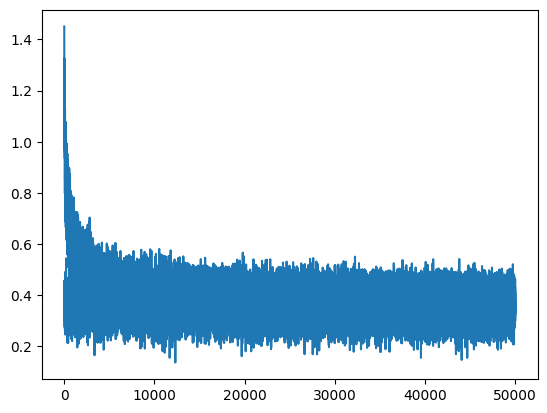

In [142]:
plt.plot(stepi, lossi)

In [138]:
print(loss.item())

2.588672637939453


In [31]:
F.cross_entropy(logits, Y)

tensor(17.7697)

In [46]:
torch.randint(0, X.shape[0], (32,))

tensor([ 38866,  66418, 210924,  90239,  29742, 174542,  82133,   8728,  93608,
         23041,  89883, 209442,  97986,  32449,  53164, 112876, 134893, 125804,
         14830,  68479,  72899, 199365,  32327,  39027,  54315,  38385, 103831,
        148812, 204443, 205459, 127127, 221505])

In [141]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2969, grad_fn=<NllLossBackward0>)

In [143]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3342, grad_fn=<NllLossBackward0>)

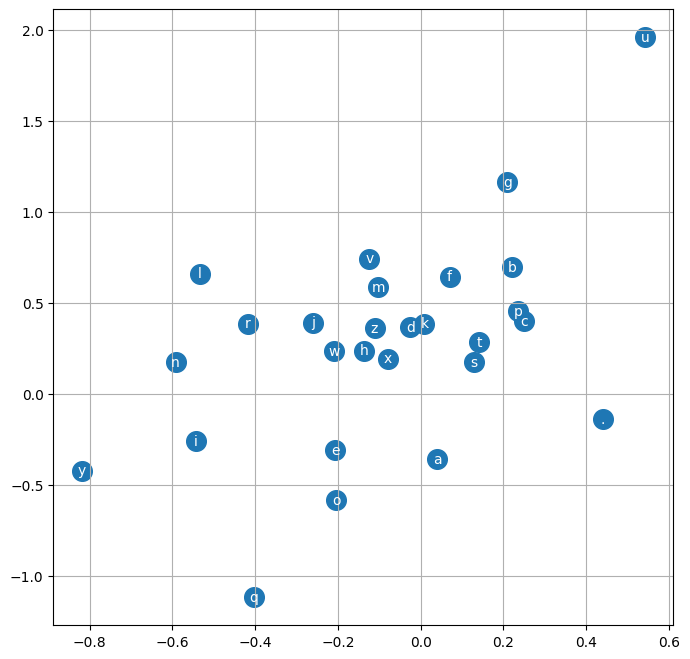

In [126]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# Training Split  - Train parameters
# Dev/Validation Split  - Train hyperparameters
# Test Split    - Evaluate performance at the end

# 80%, 10%, 10%